In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import SRW as SRW
from scipy.sparse import csr_matrix, csc_matrix, issparse
import functools

In [3]:
# Cell 2
nsamples = 100
nnodes = 1000
edge_freq = 0.004
cliq_edge_freq = 0.114
hi_mut_freq = 0.5
hi_node = nnodes * 3 / 4

group_labels = ['Subtype 1'] * (nsamples // 2) + ['Subtype 2'] * (nsamples // 2)

feature_names = [
    'Subnetwork 1',
    'Subnetwork 2',
    'High mut source',
    'High mut target',
    'Random 1',
    'Random 2',
    'Self loop',
    'Intercept'
]

node_names = [f'{i}' for i in range(1, nnodes + 1)]
sample_names = [f'{i}' for i in range(1, nsamples + 1)]

rand_mut_freq = 0.015

In [4]:
rst_prob = 0.3
lam = 1e-1
WMW_b = 2e-4

In [5]:
from scipy.sparse import csr_matrix, csc_matrix
import numpy as np

# simulate network
degrees = [0] * nnodes
edges = []
features = []    # columns: [cliq1, cliq2, hi_mut_source, hi_mut_target, rand1, rand2, self_loop, intercept]

rng = np.random.default_rng(123)

for i in range(nnodes - 1):
    for j in range(i + 1, nnodes):
        if ((i < 100 and j < 100) and rng.random() < cliq_edge_freq) or rng.random() < edge_freq:
            edges.append([i, j])
            edges.append([j, i])

            # base: no subnet, no high mut, random edge features, no self-loop, intercept=1
            features.append([0, 0, 0, 0, rng.random(), rng.random(), 0, 1])
            features.append([0, 0, 0, 0, rng.random(), rng.random(), 0, 1])

            # Subnetwork 1: nodes 0–49
            if i < 50 and j < 50:
                features[-2][0] = 1
                features[-1][0] = 1

            # Subnetwork 2: nodes 50–99
            if (50 <= i < 100) and (50 <= j < 100):
                features[-2][1] = 1
                features[-1][1] = 1

            degrees[i] += 1
            degrees[j] += 1

# simulate P_init (sample by node)
P_init = []
for i in range(nsamples):
    p_init = [0] * nnodes

    # high mutation nodes for subtype 1
    if i < (nsamples / 2):
        for j in range(50):
            if rng.random() < hi_mut_freq:
                p_init[j] = 1.0 / (degrees[j] + 1)
                p_init[i] = 1.0 / (degrees[i] + 1)

    # high mutation nodes for subtype 2
    elif i <= (nsamples - hi_node):
        for j in range(50, 100):
            if rng.random() < hi_mut_freq:
                p_init[j] = 1.0 / (degrees[j] + 1)
                p_init[i] = 1.0 / (degrees[i] + 1)

    # random background mutations
    for j in range(nnodes):
        if rng.random() < rand_mut_freq:
            p_init[j] = 1.0 / (degrees[j] + 1)
            p_init[i] = 1.0 / (degrees[i] + 1)

    P_init.append(p_init)

edges = np.array(edges, dtype=int)
features = csc_matrix(features)
P_init = csr_matrix(P_init)

# train SRW using the new torch-based implementation
model, history = SRW.train_srw_torch_dense(
    edges=edges,
    edge_features=features,
    P_init_train_csr=P_init,
    group_labels_train=group_labels,
    rst_prob=rst_prob,
    lam=lam,
    norm_type="L1",
    WMW_b=WMW_b,
    P_init_val_csr=P_init,
    group_labels_val=group_labels,
    lr=0.5,
    max_epochs=1000,
    early_stop=10,
    device=None,
)

[Epoch 001] loss=15.2683 wmw=15.2640 reg=0.0422 acc_train=0.9400 | wmw_val=3.4395 acc_val=1.0000
[Epoch 002] loss=14.6101 wmw=14.2629 reg=3.4721 acc_train=0.9400 | wmw_val=3.1810 acc_val=1.0000
[Epoch 003] loss=13.1796 wmw=12.7097 reg=4.6998 acc_train=0.9500 | wmw_val=2.7946 acc_val=1.0000
[Epoch 004] loss=10.9448 wmw=10.4296 reg=5.1517 acc_train=0.9600 | wmw_val=2.2399 acc_val=1.0000
[Epoch 005] loss=8.6152 wmw=7.9960 reg=6.1919 acc_train=0.9700 | wmw_val=1.6523 acc_val=1.0000
[Epoch 006] loss=6.9906 wmw=6.1971 reg=7.9349 acc_train=0.9700 | wmw_val=1.2010 acc_val=1.0000
[Epoch 007] loss=6.1052 wmw=5.2092 reg=8.9597 acc_train=0.9600 | wmw_val=0.9270 acc_val=1.0000
[Epoch 008] loss=5.6964 wmw=4.7330 reg=9.6335 acc_train=0.9600 | wmw_val=0.7780 acc_val=1.0000
[Epoch 009] loss=5.5172 wmw=4.4931 reg=10.2410 acc_train=0.9600 | wmw_val=0.6970 acc_val=1.0000
[Epoch 010] loss=5.4036 wmw=4.3512 reg=10.5238 acc_train=0.9600 | wmw_val=0.6497 acc_val=1.0000
[Epoch 011] loss=5.3100 wmw=4.2456 reg=1

In [6]:
import pandas as pd
w_np = model.w.detach().cpu().numpy()
w_map = pd.DataFrame(w_np, index=feature_names, columns=["Weight"])
w_map

,Weight
Subnetwork 1,6.353930
Subnetwork 2,4.896491
High mut source,0.013139
High mut target,-0.021409
Random 1,-1.591784
Random 2,-2.067660
Self loop,-0.019584
Intercept,-6.096930


In [7]:
import numpy as np

# start from learned weights
w_np = model.w.detach().cpu().numpy().copy()

# preserve the same manual tweak you had before:
# last two features are ['Self loop', 'Intercept']
w_np[-1] = 100     # Intercept
w_np[-2] = -200    # Self loop

# transition matrix Q
Q = SRW.generate_Q(edges, nnodes, features, w_np)

# final P via PageRank-like iteration
P = SRW.iterative_PPR(
    Q.toarray(),
    SRW.renorm(P_init).toarray(),
    rst_prob
)

# put into a DataFrame like SRW_obj.P_fin_df
P_df = pd.DataFrame(P, index=sample_names, columns=node_names)


In [8]:
%pip install pyNBS scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pynbs as pyNBS
from sklearn.decomposition import PCA
import pandas as pd

def run_pca(P_df, n_components=10):
    """
    Replacement for old pyNBS.run_pca()
    """
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(P_df.values)

    # Build DataFrame with labeled PCs
    P_df_pca = pd.DataFrame(
        X_pca[:, :n_components],
        index=P_df.index,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    return P_df_pca, pca.components_, pca.explained_variance_ratio_

P_df_pca, pca_components, explained_variance_ratio = run_pca(P_df)

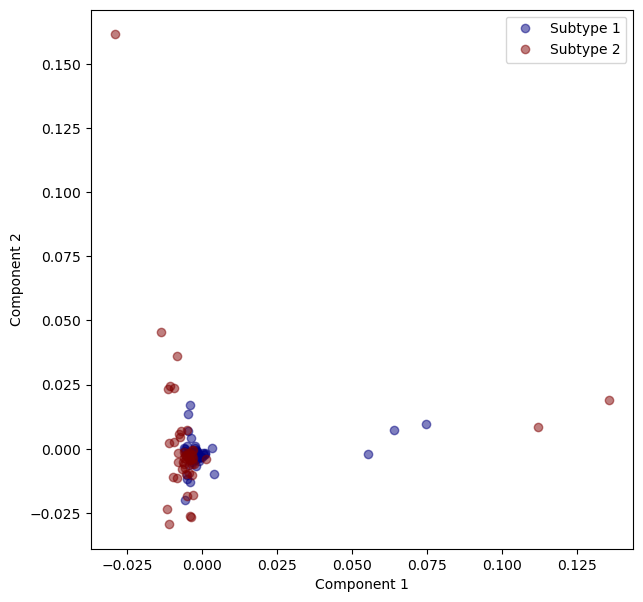

In [17]:
X = P_df_pca.copy()
X['labels'] = group_labels

labels = X.groupby('labels')

import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

cmap = plt.get_cmap('jet')
colors = cmap(np.linspace(0, 1.0, len(labels)))

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_prop_cycle(color=colors)

for name, label in labels:
    ax.plot(label.PC1, label.PC2, alpha=0.5, marker='o', linestyle='', label=name)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
ax.legend(loc='upper right')

plt.savefig('data/sim1001000_0_PCA.pdf')
plt.show()

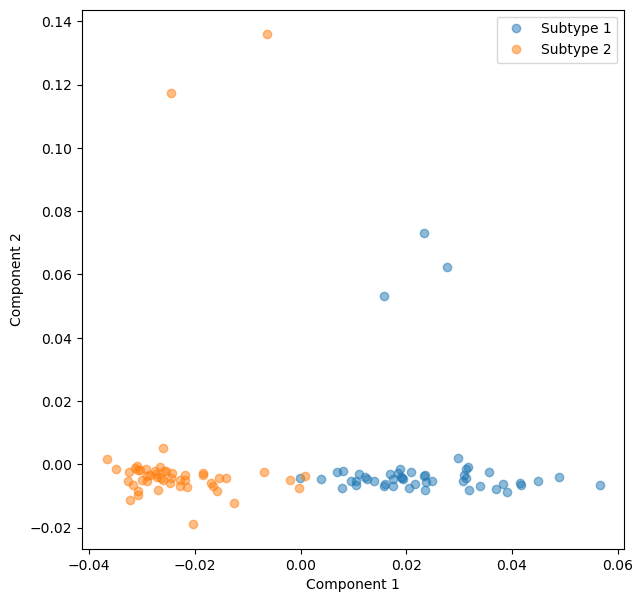

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Use the learned weights from the new model
w = model.w.detach().cpu().numpy()   # replaces SRW_obj.w_list[-1] and map_w()

# 2. Build Q with the new helper
Q = SRW.generate_Q(edges, nnodes, features, w)

# 3. Run Personalized PageRank
P = SRW.iterative_PPR(Q.toarray(), SRW.renorm(P_init).toarray(), rst_prob)

# 4. Make a DataFrame like the old P_fin_df
P_df = pd.DataFrame(P, index=sample_names, columns=node_names)
P_df_pca, pca_components, explained_variance_ratio = run_pca(P_df, n_components=10)

# 6. Plot PC1 vs PC2 by group, same as before
X = P_df_pca.copy()
X["labels"] = group_labels

labels = X.groupby("labels")

cmap = plt.get_cmap("jet")
colors = cmap(np.linspace(0, 1.0, len(labels)))

fig, ax = plt.subplots(figsize=(7, 7))

for color, (name, group) in zip(colors, labels):
    ax.plot(group.PC1, group.PC2, alpha=0.5, marker="o", linestyle="", label=name,)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
ax.legend(loc="upper right")

plt.savefig('data/sim1001000_-1_PCA.pdf')

plt.show()


In [23]:
P_df

,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
1,0.010250,0.006918,0.003437,0.010079,0.002769,0.012496,0.016125,0.010484,0.006162,0.014558,...,0.000034,0.000181,0.000033,0.000056,0.001485,0.000080,2.822338e-07,0.000006,0.000057,0.000010
2,0.007851,0.009441,0.006872,0.004102,0.001527,0.010996,0.005126,0.012293,0.003625,0.011132,...,0.000416,0.000824,0.000168,0.000398,0.000060,0.000048,2.338487e-07,0.000013,0.000132,0.000104
3,0.005799,0.007149,0.004236,0.004622,0.002916,0.006019,0.005071,0.006265,0.003632,0.007783,...,0.000022,0.000260,0.000021,0.000128,0.000014,0.000061,1.184353e-07,0.000008,0.000989,0.000037
4,0.008435,0.011325,0.006588,0.009227,0.001662,0.012741,0.010535,0.012324,0.004108,0.006969,...,0.000082,0.000424,0.000031,0.001256,0.000036,0.000732,3.472632e-07,0.000012,0.000029,0.000042
5,0.007436,0.006186,0.001638,0.002066,0.006852,0.011032,0.007431,0.010531,0.007292,0.009767,...,0.000049,0.000643,0.000384,0.000180,0.001174,0.000070,3.323386e-07,0.000144,0.000109,0.000242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.000906,0.001337,0.000462,0.001048,0.000603,0.002601,0.001284,0.001786,0.000942,0.008072,...,0.000815,0.000422,0.000466,0.000125,0.000354,0.000057,7.661024e-07,0.000011,0.000093,0.000148
97,0.000759,0.001563,0.000462,0.001193,0.000634,0.000962,0.000663,0.000911,0.001001,0.001125,...,0.000585,0.000280,0.000290,0.000254,0.000075,0.000056,5.089527e-07,0.000475,0.000089,0.000187
98,0.000569,0.002327,0.000487,0.000431,0.000585,0.002601,0.000836,0.001579,0.000841,0.002590,...,0.000062,0.000207,0.002459,0.001446,0.000089,0.000009,2.846047e-07,0.000010,0.000062,0.000092
99,0.003058,0.002740,0.002426,0.001463,0.000673,0.004836,0.002019,0.003060,0.001611,0.005574,...,0.000610,0.004410,0.000088,0.001680,0.000178,0.000407,5.614206e-07,0.000806,0.000076,0.000131


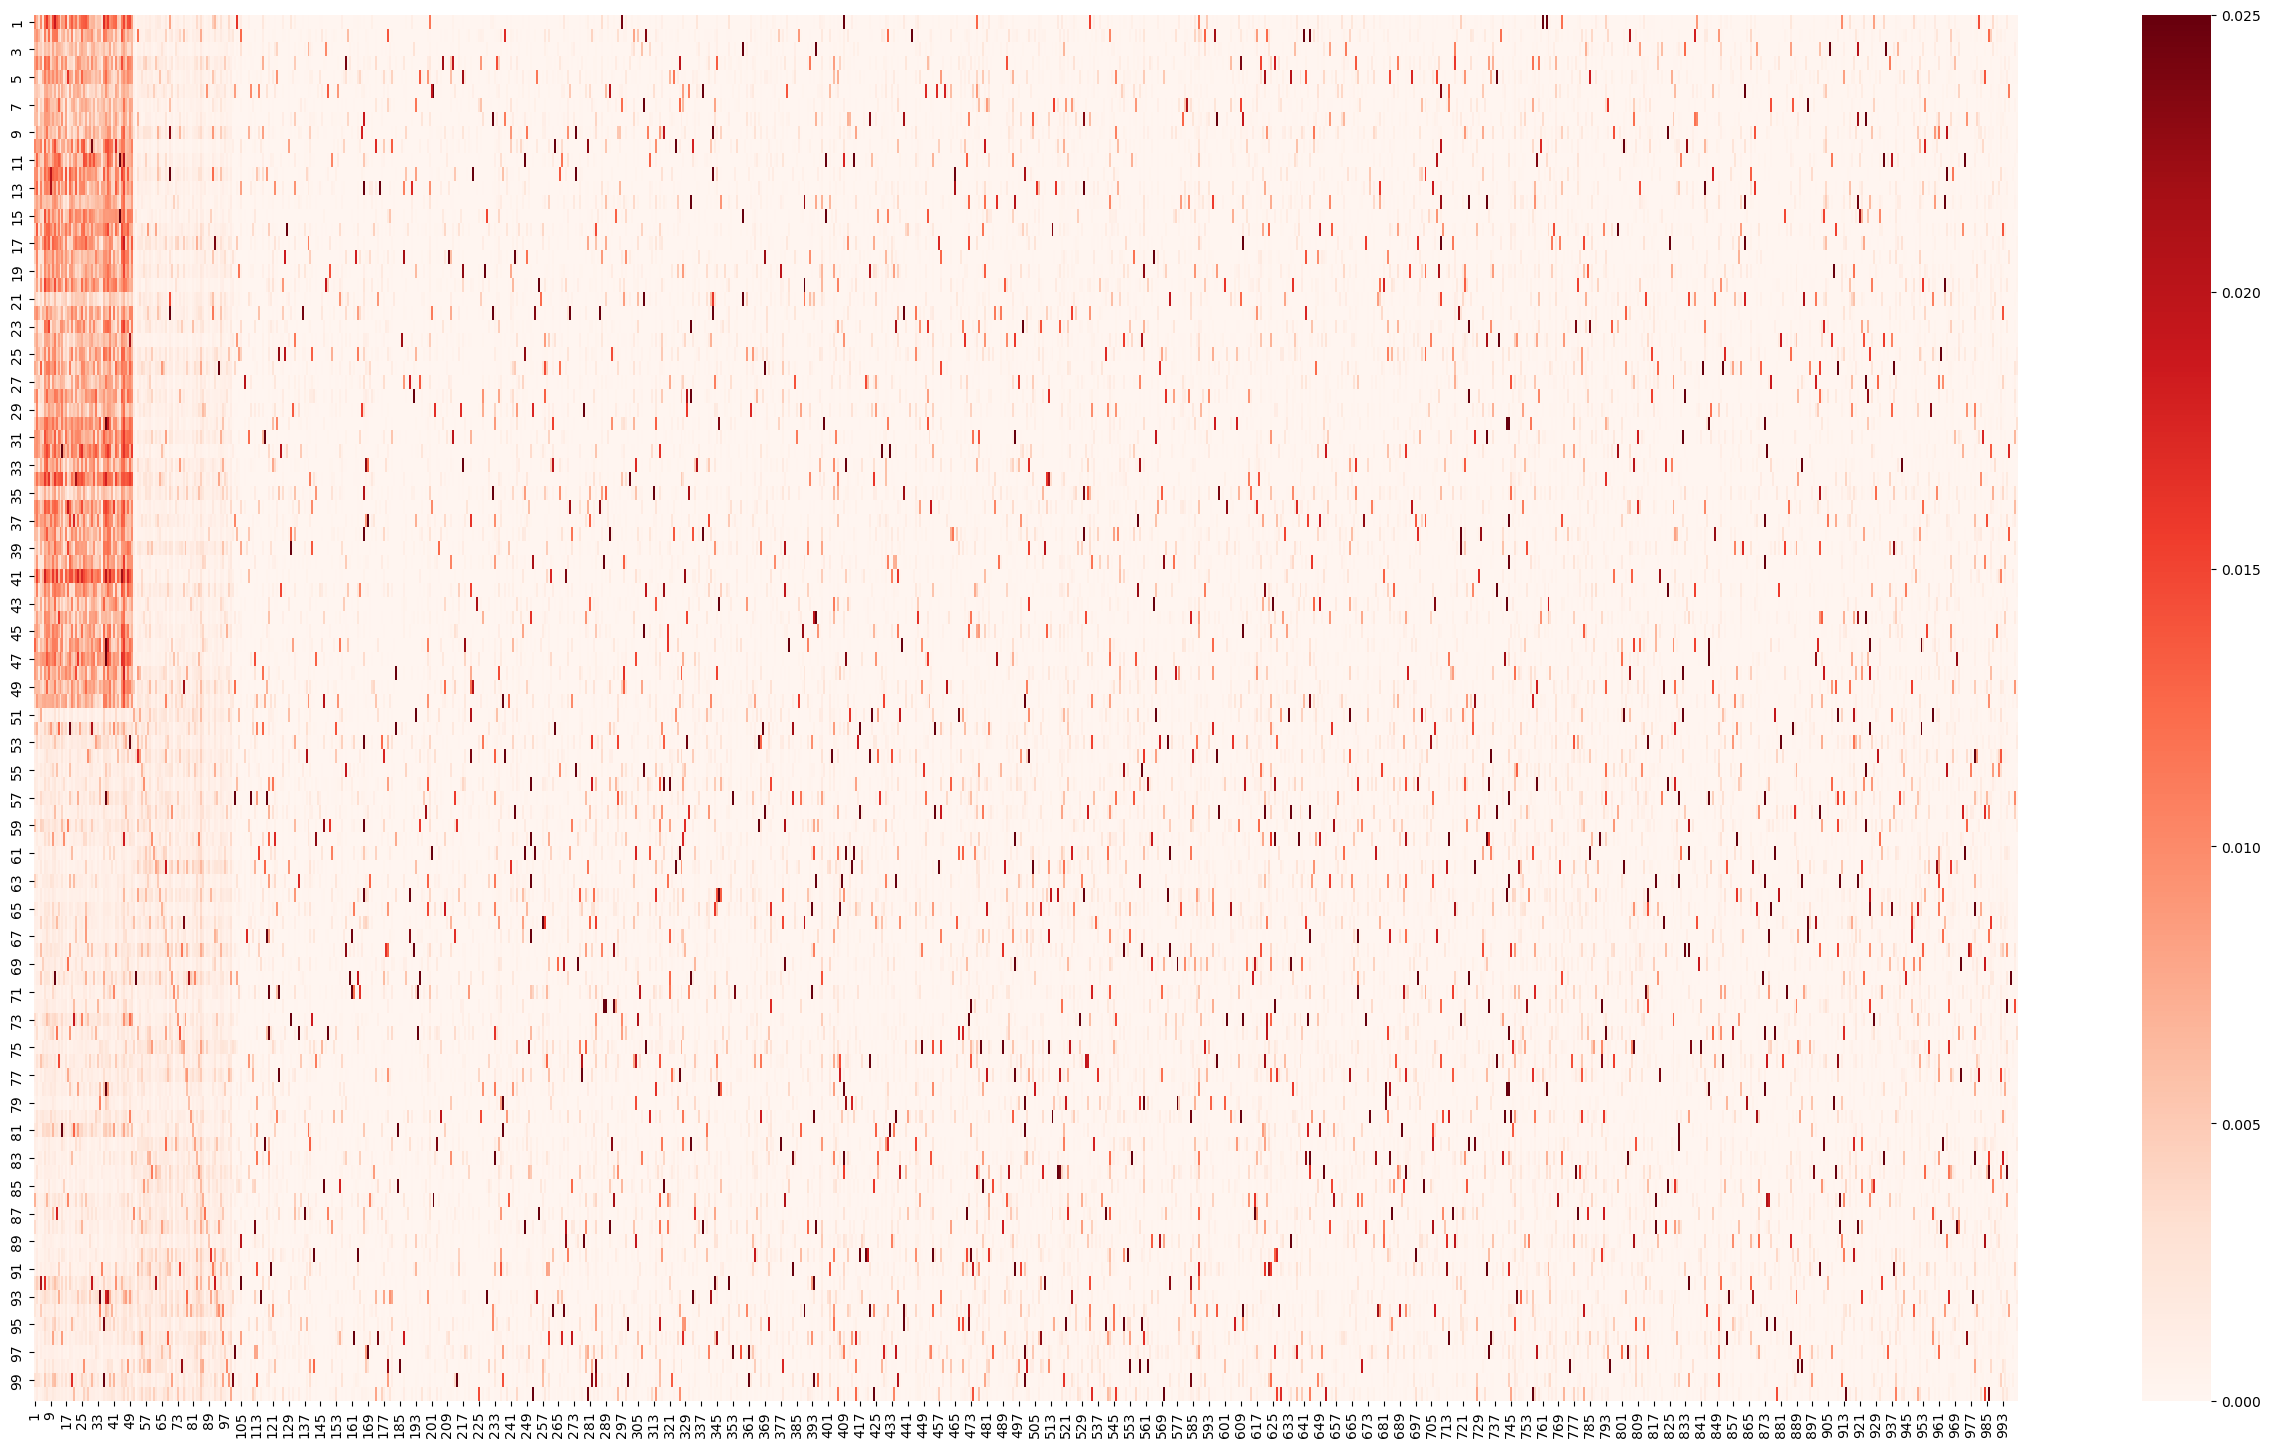

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(32,18))
ax = sns.heatmap(P_df.clip(upper=0.025),cmap='Reds', square=False)
plt.savefig('data/sim1001000_P_df.pdf')